Далее будет сделаны импорты, необходимые для выполнения работы.  В процессе работы иимпорты будут добавляться 

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import Lasso, LinearRegression
from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression

from pandas.plotting import scatter_matrix

np.random.seed(123)

In [64]:
ds_original = pd.read_csv("../data/V4.csv", index_col=0)

Работа с исходными данными
=

Описатальная статистика
-

<font size = 4>Считаем файл в DataFrame и выведем информацию о нём. Параметр ф-ции read_csv index_col, использовался, что первый столбик сделать индексом(так как это они и есть, если посмотреть на файл).<font>

In [65]:
ds_original.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Customer Name        500 non-null    str    
 1   Customer e-mail      500 non-null    str    
 2   Country              500 non-null    str    
 3   Gender               244 non-null    float64
 4   Age                  500 non-null    int64  
 5   Annual Salary        500 non-null    float64
 6   Credit Card Debt     500 non-null    float64
 7   Net Worth            500 non-null    float64
 8   Car Purchase Amount  500 non-null    float64
dtypes: float64(5), int64(1), str(3)
memory usage: 35.3 KB


Теперь посмотрим на о как выглядят значения 

In [66]:
ds_original.head()

,Customer Name,Customer e-mail,Country,Gender,Age,Annual Salary,Credit Card Debt,Net Worth,Car Purchase Amount
0,Martina Avila,cubilia.Curae.Phasellus@quisaccumsanconvallis.edu,USA,0.0,42,62812.09301,11609.380910,238961.2505,35321.45877
1,Harlan Barnes,eu.dolor@diam.co.uk,USA,0.0,41,66646.89292,9572.957136,530973.9078,45115.52566
2,Naomi Rodriquez,vulputate.mauris.sagittis@ametconsectetueradip...,USA,NaN,43,53798.55112,11160.355060,638467.1773,42925.70921
3,Jade Cunningham,malesuada@dignissim.com,USA,NaN,58,79370.03798,14426.164850,548599.0524,67422.36313
4,Cedric Leach,felis.ullamcorper.viverra@egetmollislectus.net,USA,1.0,57,59729.15130,5358.712177,560304.0671,55915.46248


Тут можно видеть, что некоторые колонки имеют неоптимальный тип данных(например пол - он может быть bool, а не float). Также я уверен, что колонку Country можно отредачить и привести к типу данных int, а также есть сомнительные столбцы для анализа ключевого Car Purchase Amount , как например Customer e-mail. Также я бы воззможно в будущем объединил Annual Salary и Credit Card Debt и Net Worth, чтобы понимать общие финансовые возможности человека.  Выведу статистику для числовых значений.

In [67]:
ds_original.describe()


,Gender,Age,Annual Salary,Credit Card Debt,Net Worth,Car Purchase Amount
count,244.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,0.500000,46.224000,62127.239608,9607.645049,431475.713625,44209.799218
std,0.501028,7.990339,11703.378228,3489.187973,173536.756340,10773.178744
min,0.000000,20.000000,20000.000000,100.000000,20000.000000,9000.000000
25%,0.000000,41.000000,54391.977195,7397.515792,299824.195900,37629.896040
50%,0.500000,46.000000,62915.497035,9655.035568,426750.120650,43997.783390
75%,1.000000,52.000000,70117.862005,11798.867487,557324.478725,51254.709517
max,1.000000,70.000000,100000.000000,20000.000000,1000000.000000,80000.000000


Тут можно заметитть интересную статистику - машины покупают люди всех возрастов от 20 до 70, больше пока не могу сказать ничего интересного. Дальше перейдём вузуализации данных. Построим гистограммы для кадлой колонки. Для кадого параметра буду писать код в отдельном сегменте кода с пояснениями к своим действиям. Визуализации Customer Name, Customer e-mail, потому что эти данные не несут никакой ценноси.

Одномерная визуализация данных
-

Начну с построения гистограммы для стран, чтобы понять в каких странах чаще покупают машины и какие страны в целом есть. Чтобы посчитатать в каких странах сколько покупок сделано, применю функцию value_counts.

In [68]:
countries = ds_original["Country"].value_counts()
print(countries)

Country
USA    500
Name: count, dtype: int64


Как выяснилось, все данные взяты из USA, так что столбец Country можно дальше не анализировать, в также он не имеет ценности для анализа и его можно будет удалить в дальнейшем

Теперь проанализируем столбец Gender, чтобы понять какой пол покупает больше машин. Единственное есть пробоема с тем, что больеш половины данных имеют пустые значения, так что сомневаюсь на сколько можно считать полученный график правдивым в рамках датасета. Также будет использована функция value_count. 

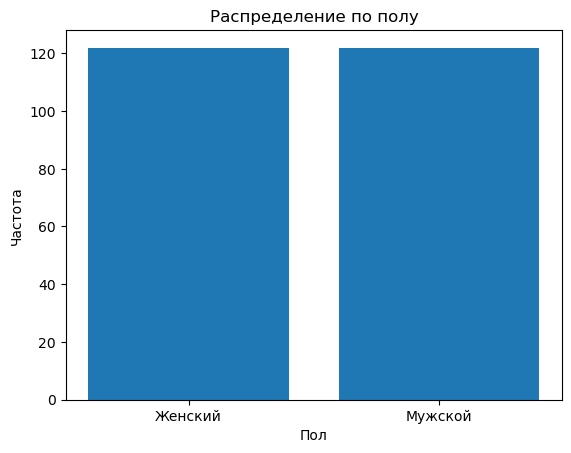

In [69]:
genders_origin = ds_original.Gender.value_counts()

plt.bar(genders_origin.index, genders_origin.values)
plt.title('Распределение по полу')
plt.xlabel('Пол')
plt.ylabel('Частота')
plt.xticks([0, 1], ['Женский', 'Мужской'])
plt.show()




Можем видеть, что люди разных полов одинаково часта покупают машины, из этого можно сделать вывод, что все пропущенные значения можно заполнить также 50/50. Это и сделаем.

In [70]:
nan_count = ds_original['Gender'].isna().sum()
fill_values = np.array([0] * 128 + [1] * 128)
np.random.shuffle(fill_values)
ds_original.loc[ds_original['Gender'].isna(), 'Gender'] = fill_values


Дальше перейду к анализу поля Age

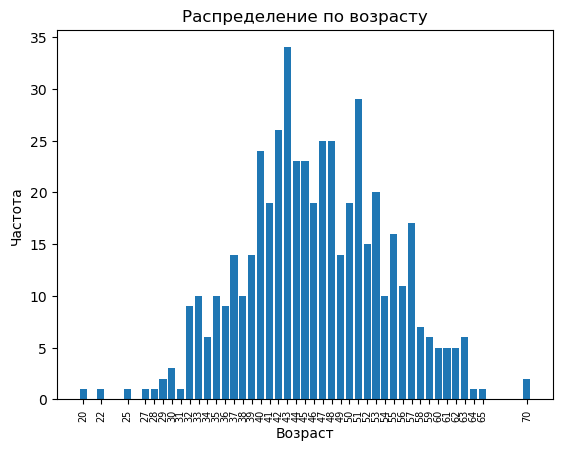

In [71]:
ages_origin = ds_original.Age.value_counts()
plt.bar(ages_origin.index, ages_origin.values)
plt.title("Распределение по возрасту")
plt.xlabel("Возраст")
plt.xticks(ages_origin.index, rotation=90, fontsize=7) 
plt.ylabel("Частота")
plt.show()

На графике видно, что большая часть людей покупает машины в возрасте 43 лет. Так же в целом можно заметить, что в юном и пожилом возрасте люди покупают машины меньше, это можно связать с финансовыми возмностями в этом возрасте и в отсутствии потребности в приобретении новых автомобилей(это скорей про старшие возраста). 

Перейду к анализу Annual_salary

In [72]:
annual_salary_origin = ds_original["Annual Salary"].value_counts()
annual_salary_origin = annual_salary_origin.sort_index()

annual_salary_origin

Annual Salary
20000.00000     1
32697.98161     1
33422.99683     1
34154.77654     1
35069.41886     1
               ..
90556.62686     1
91083.73918     1
92455.72807     1
92471.17612     1
100000.00000    1
Name: count, Length: 500, dtype: int64

Как можно видеть, все значения уникальны и по гистограмме оценить распределение нельзя. Я предлагаю кластеризировать значения, чтобы было возможно построить график

In [235]:
a = 1500
bins = range(20000, 100000, a)
labels = [str(x) for x in bins[:-1]]

annual_salary_grouped_origins =  pd.cut(annual_salary_origin.index,  bins=bins, labels=labels).value_counts()


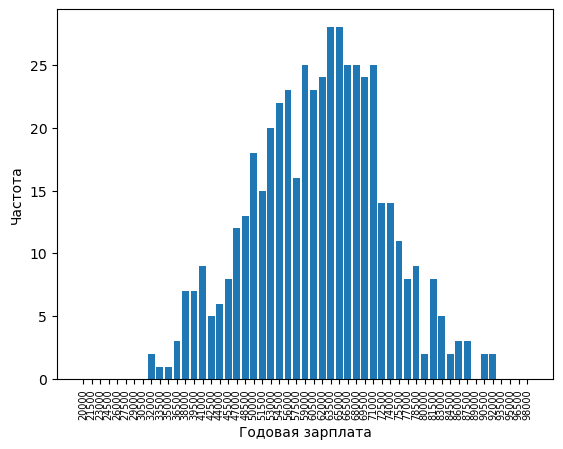

In [236]:
plt.bar(annual_salary_grouped_origins.index, annual_salary_grouped_origins.values)
plt.xlabel("Годовая зарплата")
plt.ylabel("Частота")
plt.xticks(annual_salary_grouped_origins.index, rotation=90, fontsize=7)
plt.show()


На изображении мы можем сделать вывод, что распределение стремится к нормальному и больше всего получают зарплату в размере 60000. 

Далее перейдём к Credit Card Debt, действия будут аналогичные. Только теперь будем использовать функцию cut

In [237]:
credit_card_debt_origin = ds_original["Credit Card Debt"].value_counts()
credit_card_debt_origin = credit_card_debt_origin.sort_index()

credit_card_debt_origin

Credit Card Debt
100.000000      1
594.804949      1
632.052852      1
640.045378      1
861.816653      1
               ..
17870.637650    1
18361.249150    1
18693.146520    1
19692.912620    1
20000.000000    1
Name: count, Length: 500, dtype: int64

In [238]:
a = 500
bins = range(100, 20100, a)
labels = [str(x) for x in bins[:-1]]

credit_card_debt_grouped_origin = pd.cut(credit_card_debt_origin.index,  bins=bins, labels=labels).value_counts()

credit_card_debt_grouped_origin

100       1
600       6
1100      0
1600      4
2100      3
2600      5
3100      3
3600      7
4100      8
4600     14
5100      9
5600     14
6100     16
6600     22
7100     23
7600     29
8100     22
8600     29
9100     28
9600     35
10100    23
10600    32
11100    31
11600    23
12100    18
12600    15
13100    15
13600    15
14100    14
14600     7
15100     8
15600     4
16100     4
16600     3
17100     3
17600     2
18100     1
18600     1
19100     0
Name: count, dtype: int64

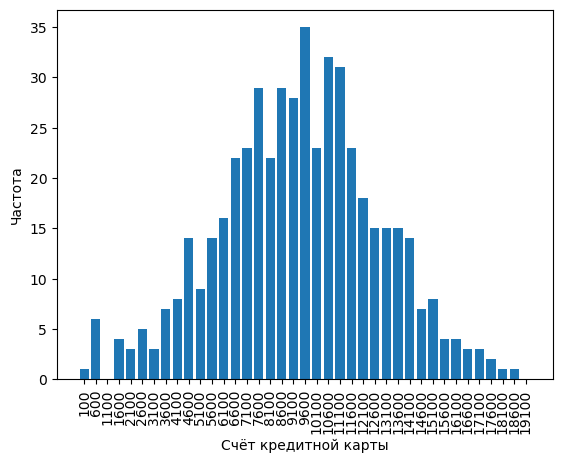

In [239]:
plt.bar(credit_card_debt_grouped_origin.index, credit_card_debt_grouped_origin.values)
plt.xlabel("Счёт кредитной карты")
plt.ylabel("Частота")
plt.xticks( rotation=90) 
plt.show()


Опять видно, что распределение стремится к нормальному и большая часть значений сосредоточена около 9600. Вообще можно преждевременно сделать вывод о том, что все данные стремятся к нормальному распределенью  в этом датасете. Дальше перейдём Net Worth

In [240]:
net_worth_origin = ds_original["Net Worth"].value_counts()
net_worth_origin = net_worth_origin.sort_index()

net_worth_origin

Net Worth
20000.00000      1
27888.74525      1
48620.32123      1
53366.13861      1
59630.07789      1
                ..
853913.85320     1
854283.55740     1
856287.15220     1
891439.87610     1
1000000.00000    1
Name: count, Length: 500, dtype: int64

In [241]:
a = 20000
bins = range(20000, 1000000, a)
labels = [str(x) for x in bins[:-1]]

net_worth_grouped_origin =  pd.cut(net_worth_origin.index,  bins=bins, labels=labels).value_counts()

net_worth_grouped_origin

20000      1
40000      3
60000      3
80000      2
100000     2
120000     7
140000     9
160000    10
180000     6
200000    14
220000    14
240000    17
260000    16
280000    21
300000    15
320000    18
340000    23
360000    21
380000    20
400000    23
420000    15
440000    13
460000    22
480000    24
500000    21
520000    15
540000    20
560000    24
580000    13
600000    17
620000    21
640000     6
660000     8
680000     5
700000     4
720000     3
740000     2
760000     8
780000     4
800000     3
820000     1
840000     3
860000     0
880000     1
900000     0
920000     0
940000     0
960000     0
Name: count, dtype: int64

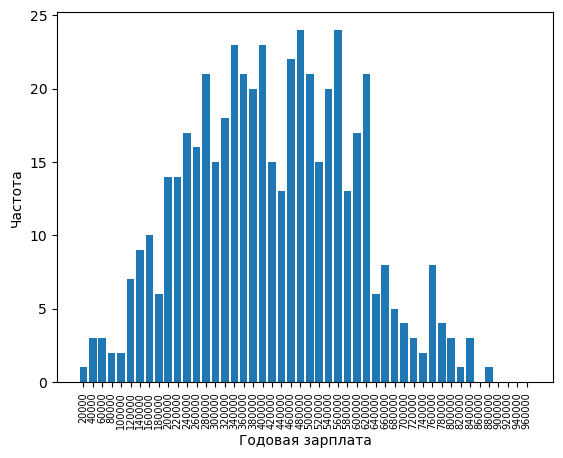

In [242]:
plt.bar(net_worth_grouped_origin.index, net_worth_grouped_origin.values)
plt.xlabel("Годовая зарплата")
plt.ylabel("Частота")
plt.xticks(rotation=90, fontsize=7)
plt.show()

Car Purchase Amount Тут надо отметить, что распределение данных чисто визуально сильно отличается от нормального распределения, дальше перейдём к последнему числовому полю Car Purchase Amount. Проделамем те же действия: разделим на опредлённые подкатегории и построим гистограмму. 

In [243]:
car_purchase_amount_origin = ds_original["Car Purchase Amount"].value_counts()
car_purchase_amount_origin = car_purchase_amount_origin.sort_index()
car_purchase_amount_origin

Car Purchase Amount
9000.00000     1
10092.22509    1
12536.93842    1
12895.71468    1
17584.56963    1
              ..
68925.09447    1
69669.47402    1
70598.96768    1
70878.29664    1
80000.00000    1
Name: count, Length: 500, dtype: int64

In [244]:
a = 2000
bins = range(9000, 80000, a)
labels = [str(x) for x in bins[:-1]]
car_purchase_amount_groped_origin =  pd.cut(car_purchase_amount_origin.index, bins=bins, labels=labels).value_counts()

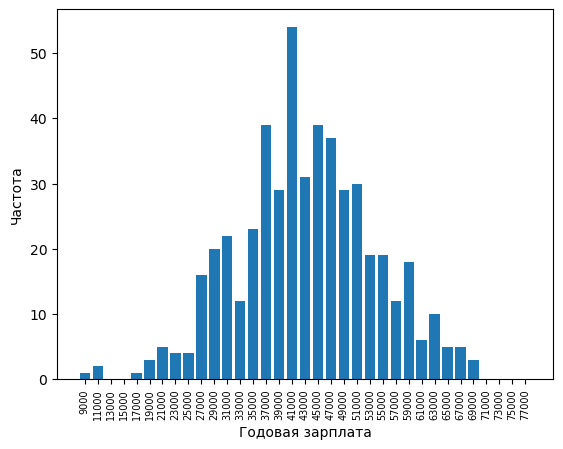

In [245]:
plt.bar(car_purchase_amount_groped_origin.index, car_purchase_amount_groped_origin.values)
plt.xlabel("Годовая зарплата")
plt.ylabel("Частота")
plt.xticks(rotation=90, fontsize=7)
plt.show()

Тут видно, что распределение может напоминать нормальное, однако сумма в районе 41000 сильно выбивается вперёд.

Вообще если делать общие выводы, то можно сказать, что выбросов нигде не наблюдается и в среднем распределение стремится к нормальному.

Двумерная визуализация данных
-

Далее перейдём к анализу полей относительно поля Car Purchase Amount для выявления связей между этими приизнаками и Car Purchase Amount.

<Axes: >

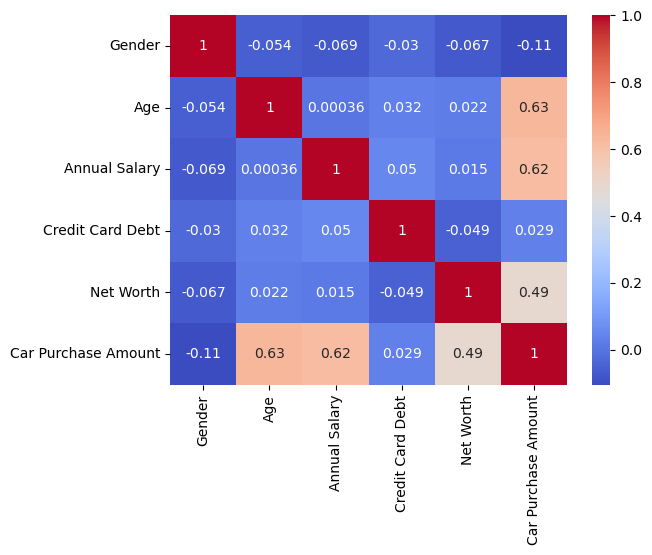

In [246]:
numeric_cols = ["Gender", "Age", "Annual Salary", "Credit Card Debt", "Net Worth","Car Purchase Amount"]
corr_matrix = ds_original[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap = 'coolwarm')

Тут мы можем видеть, что с Car Purchase Amount лучше всего коррелируют Age, Annual Salary и немного коррелирует NetWorth. Чтобы убедится в этом, построю матрицу диаграммы рассеяния.

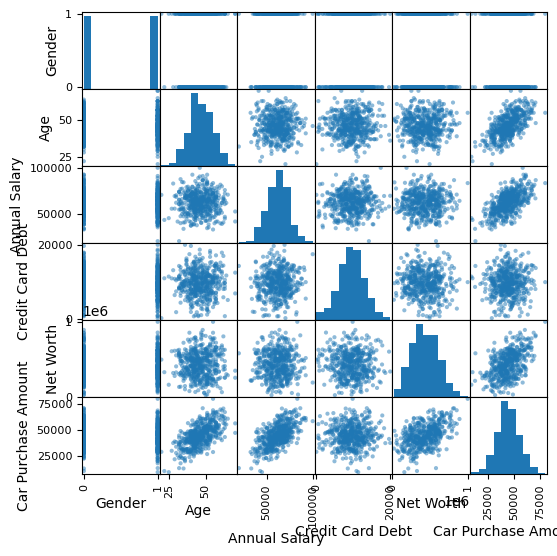

In [247]:
scatter_matrix(ds_original[numeric_cols], figsize=(6,6))
plt.show()

Тут мы тоже можем видеть, что Car Purchase Amout зависит  от Age, Annual Salary и Net Worth. Так что моё предположение верно. Credit Card Dept и Car Purchase не похоже, что связаны хоть как-то , также как и с Gender(там вообще сложно говорить о какой-то связи , так как данные распределены равномерно и являются бинарными). Про Credit Card Dept можно только сказать, что наибольшее число значений сконцентрировано именно в середине значений , но сомневаюсь, что это может говорить о какой-то функциональной зависимости, тем более, что карта корреляции это подтверждает.

Линейная регрессия
-

Сейчас разделим выборку для данных на обучающую, контрольную и тестовую

In [248]:
ds_original_learn, ds_original_control = train_test_split(ds_original, test_size=0.2)
ds_original_control, ds_original_test = train_test_split(ds_original_control, test_size= 0.5)

Теперь выделим от сюда X и Y, в качестве Y будут выступать значения столбца Car Purchase Amount , в качестве параметров X выступают столбцы Age, Annual Salary, Credit Card Debt, Net Worth

In [249]:
Y_original_learn = ds_original_learn["Car Purchase Amount"]
Y_original_control = ds_original_control["Car Purchase Amount"]
Y_original_test = ds_original_test["Car Purchase Amount"]

X_original_learn = ds_original_learn[["Age","Annual Salary", "Credit Card Debt", "Net Worth"]]
X_original_control = ds_original_control[["Age","Annual Salary", "Credit Card Debt", "Net Worth"]]
X_original_test = ds_original_test[["Age","Annual Salary", "Credit Card Debt", "Net Worth"]]

Перейдём к обучению модели и выводе метрик, также возможно придётся подбирать значения alpha

In [250]:
model_lasso = Lasso(alpha=0.5)
model_lasso.fit(X= X_original_learn, y=Y_original_learn)

y_pred_learn = model_lasso.predict(X_original_learn)

model_r2_learn_original = r2_score(Y_original_learn, y_pred_learn)
model_MSE_learn_original = np.sqrt( mean_squared_error(Y_original_learn, y_pred_learn))

print("RMSE on learning: ", model_MSE_learn_original )
print("R2 on learning: ", model_r2_learn_original)

RMSE on learning:  240.5331115939308
R2 on learning:  0.9995071246509046


Мы можем видеть крайне интересную картину, у нас крайне высокая R2 метрика, но при этом плохая MSE, можно сделать ряд предположений почему это так, но я предпочту в начале сделать проверку на контрольных значениях

In [251]:
y_pred_control = model_lasso.predict(X_original_control)

model_r2_learn_control = r2_score(Y_original_control, y_pred_control)
model_MSE_learn_control = np.sqrt(mean_squared_error(Y_original_control, y_pred_control))

print("RMSE on learning: ", model_MSE_learn_control )
print("R2 on learning: ", model_r2_learn_control)

RMSE on learning:  255.44066746459774
R2 on learning:  0.9994355380018747


Тут мы видим аналогичную ситуацию, выведу коэффициенты и свободный член

In [252]:
print(model_lasso.coef_)
print(model_lasso.intercept_)

[8.40649605e+02 5.61975362e-01 3.65703432e-03 2.89960700e-02]
-42106.483561097106


Тут стоит вспомнить в чём состоит Lasso регрессия. Она обнуляет наименьшие веса (ну или пытается обнулить) и тут всплывает проблема немасштабируемых данных исходного датасета. В нём очень большой разброс значений, например Annual Salary принимает значение [20000:100000], а Credit Card Debt [299824.195900:1000000.000000]. Проблема заключается в том, что Lasso регрессия чувствительна к масштабируемым данным (они должны быть таковыми). Из-за этого возникает такая разница в коэффициентах (839, 0.5, 0.003, 0.02). Ведь, несмотря на то, что имеется не одно хорошо коррелирующее значение, коэффициент значительный только 1. Из-за этого же возникает и проблема с RMSE.

Не стоит забывать, что мы используем в обучении параметры, которые плохо коррелиируют, что также может влиять

Я бы сказал, что в данном случае Lasso регресиия не очень подходит, посмотрим потом как она поведёт себя на масштабтрованных данных.

Полиномиальная регрессия 
-

Теперь попробуем использовать полиномиальную модель. Для базового теста предлагаю использовать полином 4 степени, так как признака 4, потом рассмотрим и другие

In [253]:
poly = PolynomialFeatures(degree=4)

X_original_learn_poly = poly.fit_transform(X_original_learn)
X_original_control_poly = poly.fit_transform(X_original_control)


In [254]:
model = LinearRegression()

model.fit(X_original_learn_poly,Y_original_learn)

y_pred_learn_poly = model.predict(X_original_learn_poly)

model_RMSE_learn_original_poly = np.sqrt(mean_squared_error(Y_original_learn, y_pred_learn_poly))
model_R2_learn_original_poly = r2_score(Y_original_learn, y_pred_learn_poly)

print("RMSE on learning poly: ", model_RMSE_learn_original_poly)
print("R2 on learning poly: ", model_R2_learn_original_poly)

RMSE on learning poly:  1178.7504256344866
R2 on learning poly:  0.9881632879176332


Хочется прервать поток кода, тут данные выглядят более многообещающими , нет гиперреалистичного R2, так что предлагаю перейти к перебору разных степеней полинома(начиная с 2 и до 6). Единственное, заметна проблема с RMSE - она очень большая 

In [255]:
degrees = [1,2,3,4,5,6]
results_rmse = []
results_r2 = []
names = []
for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_original_learn_poly = poly.fit_transform(X_original_learn)
    
    model = LinearRegression()
    model.fit(X_original_learn_poly, Y_original_learn)
    y_pred_learn_poly = model.predict(X_original_learn_poly)
    
    model_RMSE_learn_original_poly = np.sqrt(mean_squared_error(Y_original_learn, y_pred_learn_poly))
    model_R2_learn_original_poly = r2_score(Y_original_learn, y_pred_learn_poly)

    results_rmse.append(model_RMSE_learn_original_poly)
    results_r2.append(model_R2_learn_original_poly)
    names.append(degree)

    print("Degree: ", degree)
    print("RMSE: ", model_RMSE_learn_original_poly)
    print("R2: ", model_R2_learn_original_poly)

print("Names: ", names)
print("RMSE: ", results_rmse)
print("R2: ", results_r2)



Degree:  1
RMSE:  240.5331035281817
R2:  0.9995071246839596
Degree:  2
RMSE:  235.159296082913
R2:  0.9995289015646627
Degree:  3
RMSE:  357.72004881773495
R2:  0.9989098809690723
Degree:  4
RMSE:  1178.7504256344866
R2:  0.9881632879176332
Degree:  5
RMSE:  1784.4527594577376
R2:  0.9728732684757132
Degree:  6
RMSE:  2424.106828435755
R2:  0.9499399973079281
Names:  [1, 2, 3, 4, 5, 6]
RMSE:  [np.float64(240.5331035281817), np.float64(235.159296082913), np.float64(357.72004881773495), np.float64(1178.7504256344866), np.float64(1784.4527594577376), np.float64(2424.106828435755)]
R2:  [0.9995071246839596, 0.9995289015646627, 0.9989098809690723, 0.9881632879176332, 0.9728732684757132, 0.9499399973079281]


Визуализируем полученные данные

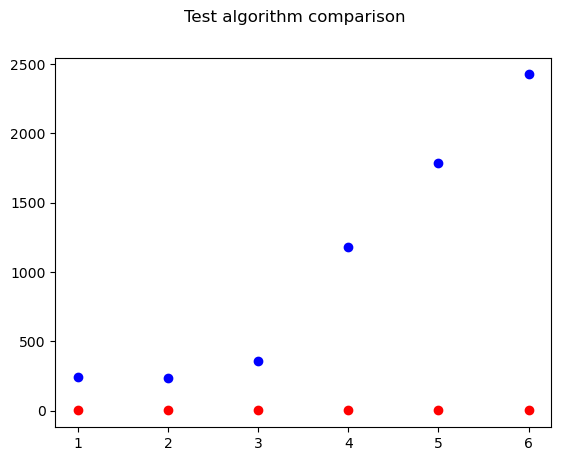

In [256]:
plt.plot(names, results_rmse, "bo")
plt.plot(names, results_r2, "ro")
plt.suptitle("Test algorithm comparison")
plt.show()

Тут видно, что лучше всего себя показывает полином со степенью 2, ведь после него RMSE уходит куда-то в небеса.
Теперь перейдём к тестам на контрольной выборке.

In [257]:
degrees = [1,2,3,4,5,6]
results_rmse = []
results_r2 = []
names = []
for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_original_learn_poly = poly.fit_transform(X_original_learn)
    X_original_control_poly = poly.fit_transform(X_original_control)
    model = LinearRegression()
    model.fit(X_original_learn_poly, Y_original_learn)
    y_pred_сontrol_poly = model.predict(X_original_control_poly)
    
    model_RMSE_learn_original_poly = np.sqrt(mean_squared_error(Y_original_control, y_pred_сontrol_poly))
    model_R2_learn_original_poly = r2_score(Y_original_control, y_pred_сontrol_poly)

    results_rmse.append(model_RMSE_learn_original_poly)
    results_r2.append(model_R2_learn_original_poly)
    names.append(degree)

    print("Degree: ", degree)
    print("RMSE: ", model_RMSE_learn_original_poly)
    print("R2: ", model_R2_learn_original_poly)

print("Names: ", names)
print("RMSE: ", results_rmse)
print("R2: ", results_r2)


Degree:  1
RMSE:  255.44074021962177
R2:  0.9994355376803327
Degree:  2
RMSE:  277.68126803257536
R2:  0.9993329662694851
Degree:  3
RMSE:  366.87095991208014
R2:  0.9988356560251193
Degree:  4
RMSE:  1805.9766797374252
R2:  0.9717850747399163
Degree:  5
RMSE:  3488.844158528394
R2:  0.8947025705296556
Degree:  6
RMSE:  6364.531921883308
R2:  0.6495810643032223
Names:  [1, 2, 3, 4, 5, 6]
RMSE:  [np.float64(255.44074021962177), np.float64(277.68126803257536), np.float64(366.87095991208014), np.float64(1805.9766797374252), np.float64(3488.844158528394), np.float64(6364.531921883308)]
R2:  [0.9994355376803327, 0.9993329662694851, 0.9988356560251193, 0.9717850747399163, 0.8947025705296556, 0.6495810643032223]


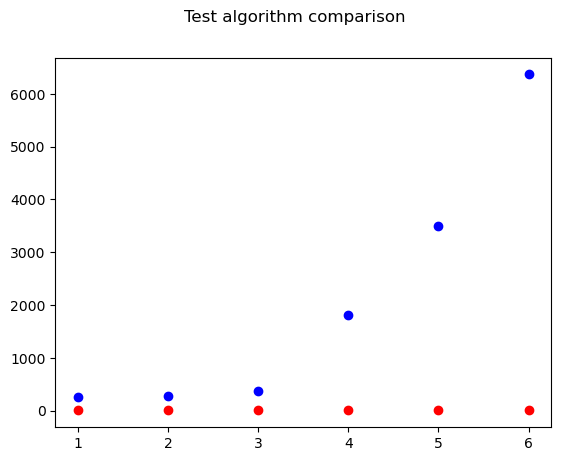

In [258]:
plt.plot(names, results_rmse, "bo")
plt.plot(names, results_r2, "ro")
plt.suptitle("Test algorithm comparison")
plt.show()

Тут мы можем видеть, что лучшей степенью является 1, но мы её брать не будем, ведь стпень 1 - это прямая , так что следующая лучшая степень - это 2, ведь после 3 степени RMSE резко начинает увеличиваться, так что я остановлюсь на этом.

Теперь надо привести равнение метрик для линейной модели и полиномиальной модели.

Сравнение
-

In [259]:
linear_rmse_origin = 241.52836711679535
linear_r2_origin = 0.9990672351744179

poly_rmse_origin = 238.39605496054642
poly_r2_origin = 0.9990665944836974

print(linear_rmse_origin-poly_rmse_origin, linear_r2_origin - poly_r2_origin)

3.132312156248929 6.406907204770107e-07


Тут можно увидеть, что полиномиальная модель со степенью полинома 2 подходит лучше. Я бы обозначил несколько проблем в текущем датасете, которые стоит учитывать при оценке:
+ Данные не масштабируемые, а это может сильно влиять на Lasso регрессию
+ В обучении модели использовались признаки, которые слабо коррелируют с целевым признаком
+ Часть потенциально полезных признаков пока не сущетсвует, потому что нельзя менять и добавлять признаки

Работа с исходными масштабированными данными
=

<font size = 3>
Теперь мне нужно выполнить масштабировать данных методом Min Max. В качестве промежутка возьму [0:1], как один из самых стандартных промежутков (если верить интернету и интуиции). 
Так как масштабирование данных никак не влияет на их распределение и корреляцию, этапы с визуализацией я предлагаю пропустить и перейти сразу к линейной регресси
Перед этим мне нужно сформировать X и Y аналогично с предыдущим, только подвергну их изменению масштаба (только X)
</font>

Масштабирование
-

In [260]:
scaler = MinMaxScaler((0, 1), copy=True)

scaler.fit(X_original_learn)

X_scaled_learn = scaler.transform(X_original_learn)
X_scaled_control = scaler.transform(X_original_control)
X_scaled_test = scaler.transform(X_original_test)


Мы в начале делаем fit по обучающей выборке (чтобы избежать утечек данных), затем изменяем все выборки . Дальше перейдём к обучению модели

Линейная регрессия
-

обучим модель и выведем метрики

In [261]:
model_lasso_scaler = Lasso(alpha=0.5)
model_lasso_scaler.fit(X_scaled_learn, Y_original_learn)

y_pred_scaled_lasso_learn = model_lasso_scaler.predict(X_scaled_learn)

model_RMSE_scaled_learn = np.sqrt(mean_squared_error(Y_original_learn, y_pred_scaled_lasso_learn))
model_R2_scaled_learn = r2_score(Y_original_learn, y_pred_scaled_lasso_learn)

print("RMSE on learning: ", model_RMSE_scaled_learn)
print("R2 on learning: ", model_R2_scaled_learn)


RMSE on learning:  240.60294553055718
R2 on learning:  0.99950683841653


In [262]:
y_pred_scaled_lasso_control = model_lasso_scaler.predict(X_scaled_control)

model_RMSE_scaled_control = np.sqrt(mean_squared_error(Y_original_control, y_pred_scaled_lasso_control))
model_R2_scaled_control = r2_score(Y_original_control, y_pred_scaled_lasso_control)

print("RMSE on control: ", model_RMSE_scaled_control)
print("R2 on control: ", model_R2_scaled_control)

RMSE on control:  255.00919021624188
R2 on control:  0.9994374433117376


In [263]:
print(model_lasso_scaler.coef_)
print(model_lasso_scaler.intercept_)

[42014.37531531 44936.00429778    57.37460858 25255.90141221]
-13439.842308922627


Тут мы видим ситуацию очень похожу на то, когда данные были не масштабированы, однако теперь я вынужден констатировать, что модель крайне хорошо обучилась. Разница также видна в коэффициентах и тут они хорошо объяснимы. Credit Card debt имеет крайне низкую корреляцию и потому имеет маленький коэффициент(по сравнению с другими). 

Можно сделать вывод, что уже на этом этапе модель справляется крайне хорошо, несмотря на не самую лучшую корреляцию у показателей и использовании тех, которые не важны.

Полиномиальная регрессия
-

Тут я буду сразу использовать подход с визуализацией, как при необработанных данных, чтобы сыкономить время и наглядно на всё посмотреть 

In [264]:
degrees = [2,3,4,5,6,7, 8]
results_rmse = []
results_r2 = []
names = []
for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_scaled_learn_poly = poly.fit_transform(X_scaled_learn)
    
    model = LinearRegression()
    model.fit(X_scaled_learn_poly, Y_original_learn)
    y_pred_learn_poly = model.predict(X_scaled_learn_poly)
    
    model_RMSE_learn_scaled_poly = np.sqrt(mean_squared_error(Y_original_learn, y_pred_learn_poly))
    model_R2_learn_scaled_poly = r2_score(Y_original_learn, y_pred_learn_poly)

    results_rmse.append(model_RMSE_learn_scaled_poly)
    results_r2.append(model_R2_learn_scaled_poly)
    names.append(degree)

    print("Degree: ", degree)
    print("RMSE: ", model_RMSE_learn_scaled_poly)
    print("R2: ", model_R2_learn_scaled_poly)

print("Names: ", names)
print("RMSE: ", results_rmse)
print("R2: ", results_r2)


Degree:  2
RMSE:  235.15929603110072
R2:  0.9995289015648703
Degree:  3
RMSE:  232.66355007972874
R2:  0.9995388480390779
Degree:  4
RMSE:  217.18750079404637
R2:  0.999598156438299
Degree:  5
RMSE:  196.1711279235622
R2:  0.9996721633244572
Degree:  6
RMSE:  163.02015782518853
R2:  0.9997736033599043
Degree:  7
RMSE:  91.69588615394004
R2:  0.9999283713010809
Degree:  8
RMSE:  1.1146465499113438e-06
R2:  1.0
Names:  [2, 3, 4, 5, 6, 7, 8]
RMSE:  [np.float64(235.15929603110072), np.float64(232.66355007972874), np.float64(217.18750079404637), np.float64(196.1711279235622), np.float64(163.02015782518853), np.float64(91.69588615394004), np.float64(1.1146465499113438e-06)]
R2:  [0.9995289015648703, 0.9995388480390779, 0.999598156438299, 0.9996721633244572, 0.9997736033599043, 0.9999283713010809, 1.0]


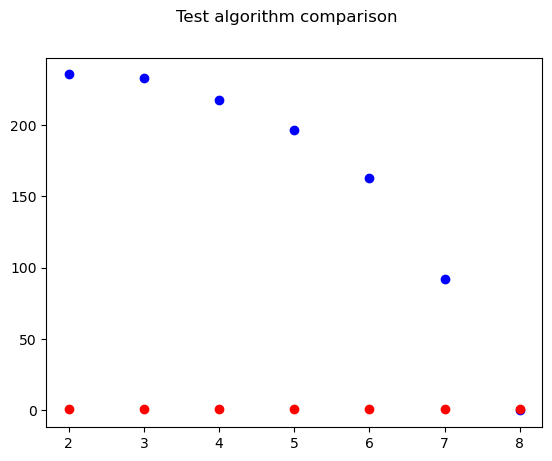

In [265]:
plt.plot(names, results_rmse, "bo")
plt.plot(names, results_r2, "ro")
plt.suptitle("Test algorithm comparison")
plt.show()

Тут можно заметить, что вплоть до degree = 7 результат плавно улулчшается, однако при degree = 8 можно заметить явное переобучение, ведь R2 = 1, a rmse примерно равно 0, что не может быть реальным. Так что оставновимся на degree = 7. Дальше проверим Эти данные на контрольной выборке аналогичным способом.

In [266]:
degrees = [2,3,4,5,6,7, 8]
results_rmse = []
results_r2 = []
names = []
for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_scaled_learn_poly = poly.fit_transform(X_scaled_learn)
    X_scaled_control_poly = poly.transform(X_scaled_control)

    model = LinearRegression()
    model.fit(X_scaled_learn_poly, Y_original_learn)
    y_pred_control_poly = model.predict(X_scaled_control_poly )
    
    model_RMSE_control_scaled_poly = np.sqrt(mean_squared_error(Y_original_control, y_pred_control_poly))
    model_R2_control_scaled_poly = r2_score(Y_original_control, y_pred_control_poly)

    results_rmse.append(model_RMSE_control_scaled_poly)
    results_r2.append(model_R2_control_scaled_poly)
    names.append(degree)

    print("Degree: ", degree)
    print("RMSE: ", model_RMSE_control_scaled_poly)
    print("R2: ", model_R2_control_scaled_poly)

print("Names: ", names)
print("RMSE: ", results_rmse)
print("R2: ", results_r2)


Degree:  2
RMSE:  277.6793037471029
R2:  0.9993329757064922
Degree:  3
RMSE:  284.09768543980437
R2:  0.9993017836423864
Degree:  4
RMSE:  404.1722351526598
R2:  0.9985868522210214
Degree:  5
RMSE:  552.3999879247076
R2:  0.9973602551642627
Degree:  6
RMSE:  1006.8190210296533
R2:  0.991230850956469
Degree:  7
RMSE:  20143.073871443732
R2:  -2.509991938209859
Degree:  8
RMSE:  529144.1353147761
R2:  -2421.1587416152192
Names:  [2, 3, 4, 5, 6, 7, 8]
RMSE:  [np.float64(277.6793037471029), np.float64(284.09768543980437), np.float64(404.1722351526598), np.float64(552.3999879247076), np.float64(1006.8190210296533), np.float64(20143.073871443732), np.float64(529144.1353147761)]
R2:  [0.9993329757064922, 0.9993017836423864, 0.9985868522210214, 0.9973602551642627, 0.991230850956469, -2.509991938209859, -2421.1587416152192]


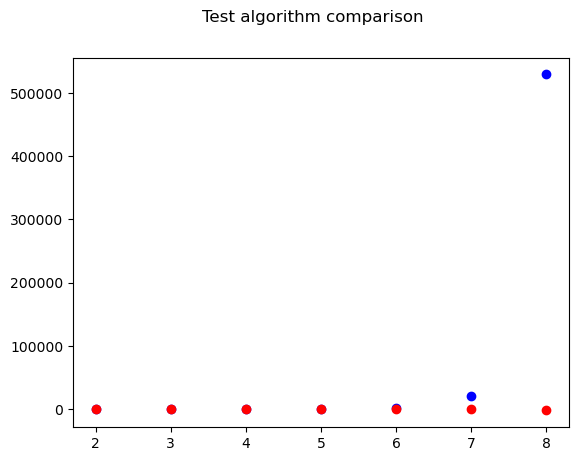

In [267]:
plt.plot(names, results_rmse, "bo")
plt.plot(names, results_r2, "ro")
plt.suptitle("Test algorithm comparison")
plt.show()

чтобы сделать резульатат более читаемым - уберу данные с degree = 8, также 6 и 7, так как там явно слишком большие начения

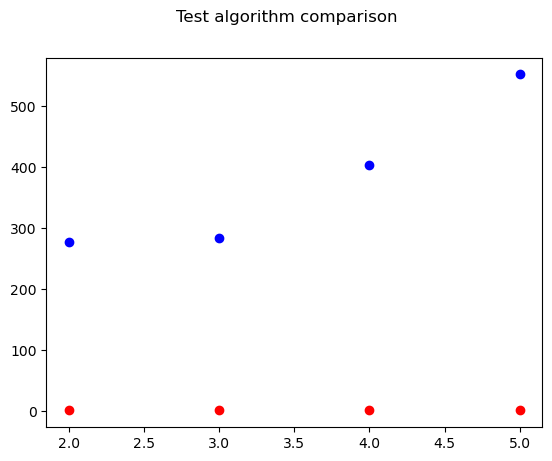

In [268]:
plt.plot(names[:-3], results_rmse[:-3], "bo")
plt.plot(names[:-3], results_r2[:-3], "ro")
plt.suptitle("Test algorithm comparison")
plt.show()

Тут мы можем очётливо видеть, что лучшая степень - 2, как и в прошлый раз(что не удивтельно), после 2 начинается переобучение, которое с 5 сильно прогрессирует, так что оставляем как лучшую степень 2. Дальше сравним линейную регрессию и полиномиальную со степенью 2

Сравнение
-

In [269]:
RMSE_on_control_liniar =  237.51655408350538
R2_on_control_linear = 0.9990734688983232


RMS_on_control_poly =  238.39624019896036
R2_on_control_poly =  0.9990665930331479

Тут можно увидеть, что линейная регрессия немного лучше, так что стоит запомнить ей как лучшую для масштабированных исходных данных. Тут уже не можно об этом однозначно сказать, так как данные масштабированы и Lasso регрессия работает хорошо. Дальше будет приведена работа с построенными данными.

Работа с построенными данными
=

Для начала нужно решить какие признаки мы хотим добавить к нашему дата сету я склоняюсь к следующим:
+ Домен почты
+ Месячная зарплата(просто более превычно для нас)
+ Общие доступные средства (net worth - задолженность по кредитке )
+ можно посчитать какую часть составляет долго от общего достатка (debt / new_worth)
+ отношение зарплаты к долгу

Также я бы убрал ряд признаков:
+ Gender
+ Credit Card Debt
+ Country
+ Customer e-mail
+ Customer Name
Однакое отбор на удаление будет выполнен специальными функциями

Скопирую ds_original в отдельный датасет, который уже буду изменять

In [270]:
ds_mod = ds_original.copy()

Перейдём к лобавлению новых признаков

In [271]:
ds_mod["Month_Salary"] = ds_mod["Annual Salary"] / 12
ds_mod["All_money"] = ds_mod["Net Worth"] - ds_mod["Credit Card Debt"]
ds_mod["Debt_net_part"] = ds_mod["Credit Card Debt"]/ ds_mod["Net Worth"]
ds_mod["Debt_salary_part"] = ds_mod["Credit Card Debt"]/ ds_mod["Annual Salary"]
ds_mod["Customer_domen"] = ds_mod["Customer e-mail"].str.split("@").str[1]

Теперь давайте поведём описательную статистику для полученного дата сета перед тем как продолжить его изменение и отбор признаков. Однако хочу отметить что одномерная визуализация будет проведена только для новых признаков.

Описательная статистика
-

In [272]:
ds_mod.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Customer Name        500 non-null    str    
 1   Customer e-mail      500 non-null    str    
 2   Country              500 non-null    str    
 3   Gender               500 non-null    float64
 4   Age                  500 non-null    int64  
 5   Annual Salary        500 non-null    float64
 6   Credit Card Debt     500 non-null    float64
 7   Net Worth            500 non-null    float64
 8   Car Purchase Amount  500 non-null    float64
 9   Month_Salary         500 non-null    float64
 10  All_money            500 non-null    float64
 11  Debt_net_part        500 non-null    float64
 12  Debt_salary_part     500 non-null    float64
 13  Customer_domen       500 non-null    object 
dtypes: float64(9), int64(1), object(1), str(3)
memory usage: 54.8+ KB


Как видим, нулевых значнений нет(они и не могли добавится), так что пойдём дальше

In [273]:
ds_mod.head()

,Customer Name,Customer e-mail,Country,Gender,Age,Annual Salary,Credit Card Debt,Net Worth,Car Purchase Amount,Month_Salary,All_money,Debt_net_part,Debt_salary_part,Customer_domen
0,Martina Avila,cubilia.Curae.Phasellus@quisaccumsanconvallis.edu,USA,0.0,42,62812.09301,11609.380910,238961.2505,35321.45877,5234.341084,227351.869590,0.048583,0.184827,quisaccumsanconvallis.edu
1,Harlan Barnes,eu.dolor@diam.co.uk,USA,0.0,41,66646.89292,9572.957136,530973.9078,45115.52566,5553.907743,521400.950664,0.018029,0.143637,diam.co.uk
2,Naomi Rodriquez,vulputate.mauris.sagittis@ametconsectetueradip...,USA,0.0,43,53798.55112,11160.355060,638467.1773,42925.70921,4483.212593,627306.822240,0.017480,0.207447,ametconsectetueradipiscing.co.uk
3,Jade Cunningham,malesuada@dignissim.com,USA,0.0,58,79370.03798,14426.164850,548599.0524,67422.36313,6614.169832,534172.887550,0.026296,0.181758,dignissim.com
4,Cedric Leach,felis.ullamcorper.viverra@egetmollislectus.net,USA,1.0,57,59729.15130,5358.712177,560304.0671,55915.46248,4977.429275,554945.354923,0.009564,0.089717,egetmollislectus.net


In [274]:
ds_mod.describe()

,Gender,Age,Annual Salary,Credit Card Debt,Net Worth,Car Purchase Amount,Month_Salary,All_money,Debt_net_part,Debt_salary_part
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,0.500000,46.224000,62127.239608,9607.645049,431475.713625,44209.799218,5177.269967,421868.068576,0.029519,0.160522
std,0.500501,7.990339,11703.378228,3489.187973,173536.756340,10773.178744,975.281519,173743.998082,0.029012,0.070467
min,0.000000,20.000000,20000.000000,100.000000,20000.000000,9000.000000,1666.666667,14911.760983,0.000202,0.001419
25%,0.000000,41.000000,54391.977195,7397.515792,299824.195900,37629.896040,4532.664766,290357.144563,0.016240,0.114060
50%,0.500000,46.000000,62915.497035,9655.035568,426750.120650,43997.783390,5242.958086,414975.061072,0.022241,0.153890
75%,1.000000,52.000000,70117.862005,11798.867487,557324.478725,51254.709517,5843.155167,550382.542879,0.035225,0.198502
max,1.000000,70.000000,100000.000000,20000.000000,1000000.000000,80000.000000,8333.333333,990125.924673,0.344100,0.713090


Тут у нас добавилось пару интересных моментов, а именно, что унекоторых людей долг составляет довольно большую часть денег (однако это редкость)

Одномерная визуализация
-

Как я уже сказал, проведу её только для новых признаков, для начала посмотрю на домены, вдруг они тоже около уникальные 

In [275]:
ds_mod.Customer_domen.value_counts()

Customer_domen
ut.org                 3
diam.co.uk             2
risusNuncac.co.uk      2
congue.edu             2
Aliquamfringilla.ca    2
                      ..
Cumsociis.ca           1
Sedmolestie.edu        1
massanonante.com       1
arcuVivamussit.net     1
hotmail.com            1
Name: count, Length: 482, dtype: int64

как мы видим, они около уникальные, однако можно попробовать выделить от туда название почтового сервиса (до точки)

In [276]:
ds_mod.Customer_domen = ds_mod.Customer_domen.str.split(".").str[0]
ds_mod.Customer_domen.value_counts()

Customer_domen
ut                5
non               4
orci              4
diam              3
at                3
                 ..
Cumsociis         1
Sedmolestie       1
massanonante      1
arcuVivamussit    1
hotmail           1
Name: count, Length: 405, dtype: int64

Значения всё ещё остаются слишком разнообразные, чтобы учитывать из в статистике, так что и визуализировать их я не буду. Перейдём к визуализации All money, как и в прошлые разы разделим из по категориям при помощи функции cut

In [277]:
all_money = ds_mod.All_money.value_counts()
all_money = all_money.sort_index()


step = 20000
bins = np.arange(ds_mod.All_money.min(), ds_mod.All_money.max(), step)
labels = [str(x.round()) for x in bins[:-1]]

all_money = pd.cut(all_money.index, bins, labels=labels).value_counts()


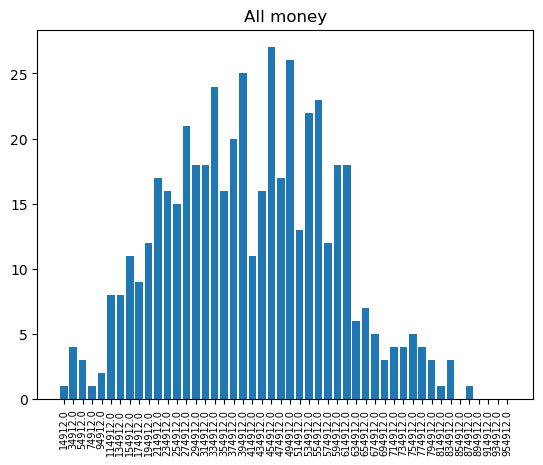

In [278]:
plt.bar(all_money.index, all_money.values)
plt.title("All money")
plt.xticks(rotation=90, fontsize=7)
plt.show()

В данном графике меня немного смущает резка просадка в районе 434911(таких зарплат мало), причём схожая просадка имеется при любом интервале, возможно это связано с тем, что в этом интервале зарплат у людей большие долги (что маловероятно) или можно предположить что по статистике подобные зарпалты дают редко, пока не понятно, так что пойдём дальше

In [279]:
month_salary = ds_mod.Month_Salary.value_counts()
month_salary = month_salary.sort_index()

step = 300
bins = np.arange(ds_mod.Month_Salary.min(),ds_mod.Month_Salary.max(), step )
labels = [str(x.round()) for x in bins[:-1] ]

month_salary = pd.cut(month_salary.index, bins, labels=labels).value_counts()


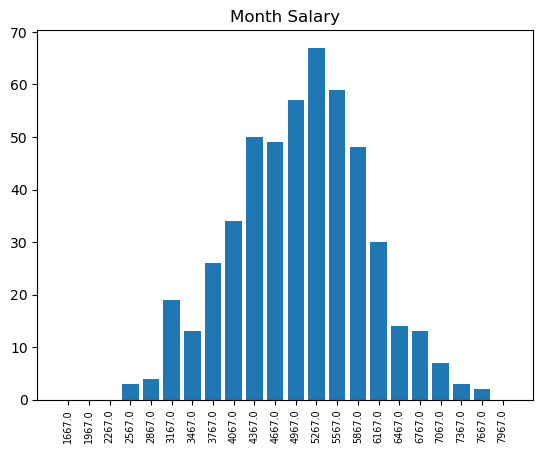

In [280]:
plt.bar(month_salary.index, month_salary.values)
plt.title("Month Salary")
plt.xticks(rotation=90, fontsize=7)
plt.show()

Тут всё аналогично с тем, что было с годовой зарплатой, так что комментировать нечего.

In [281]:
debp_net_part = ds_mod.Debt_net_part.value_counts()
debp_net_part = debp_net_part.sort_index()
print(debp_net_part)
step = 0.006
bins = np.arange(ds_mod.Debt_net_part.min(),ds_mod.Debt_net_part.max(), step )
labels = [str(x*100)[:7] for x in bins[:-1] ]

debp_net_part = pd.cut(debp_net_part.index, bins, labels=labels).value_counts()


Debt_net_part
0.000202    1
0.001022    1
0.001196    1
0.001387    1
0.001594    1
           ..
0.162963    1
0.170903    1
0.205509    1
0.254412    1
0.344100    1
Name: count, Length: 500, dtype: int64


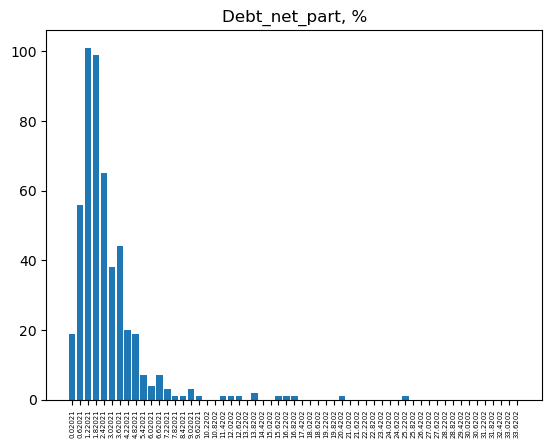

In [282]:
plt.bar(debp_net_part.index, debp_net_part.values)
plt.title("Debt_net_part, %")
plt.xticks(rotation=90, fontsize=5)
plt.show()

Тут можно отметить, что большинство людей имеют какую-никакую финансовую грамотность и долг по кредитке составлляет лишь небольшую часть от обчего достатка человека.

In [283]:
debt_salary_part = ds_mod.Debt_salary_part.value_counts()
debt_salary_part = debt_salary_part.sort_index()

step = 0.01
bins = np.arange(ds_mod.Debt_salary_part.min(),ds_mod.Debt_salary_part.max(), step )
labels = [str(x*100)[:7] for x in bins[:-1] ]

debt_salary_part = pd.cut(debt_salary_part.index, bins, labels=labels).value_counts()

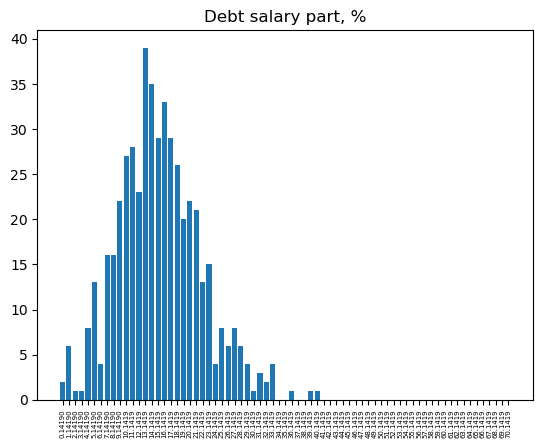

In [284]:
plt.bar(debt_salary_part.index, debt_salary_part.values)
plt.title("Debt salary part, %")
plt.xticks(rotation=90, fontsize=5)
plt.show()

Тут ситуация немного более печальная, ведь у больщинства людей процент кредина от годовой зарплаты составляет аж 15 процентов, что весьма много, как мне кажется. Дальше перейдём к двумерной визуализации.

Двумерная визуализация
-

Для начала пострую тепловую карту корреляции данных, однако только для новых признаков, так как корреляция с другими признаками меня не интересует. В этой статистике не будет учитываться Month Salary, так как это лишь линейное преобразование Annual Salary

<Axes: >

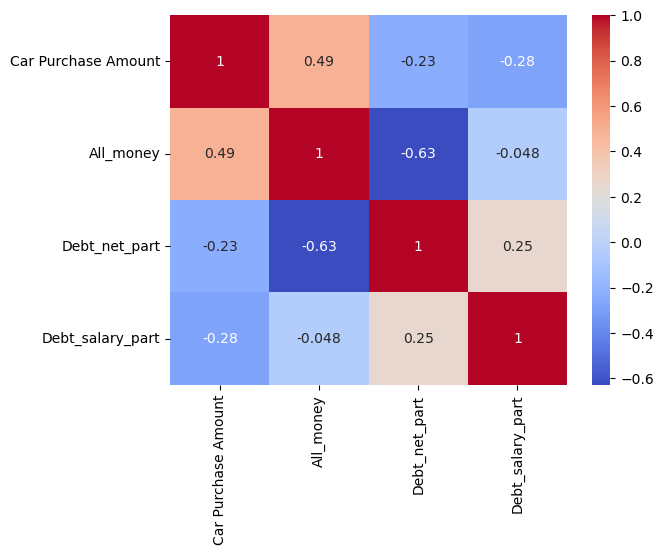

In [285]:
numeric_cols = ["Car Purchase Amount", "All_money", "Debt_net_part", "Debt_salary_part"]
corr_matrix = ds_mod[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap = 'coolwarm')

Тут можно увидеть, что единсвтенный признак, который притендует на корреляцию - это All money. Дальше хочу построить что-то типо теплового распредления точек(потому что могу)

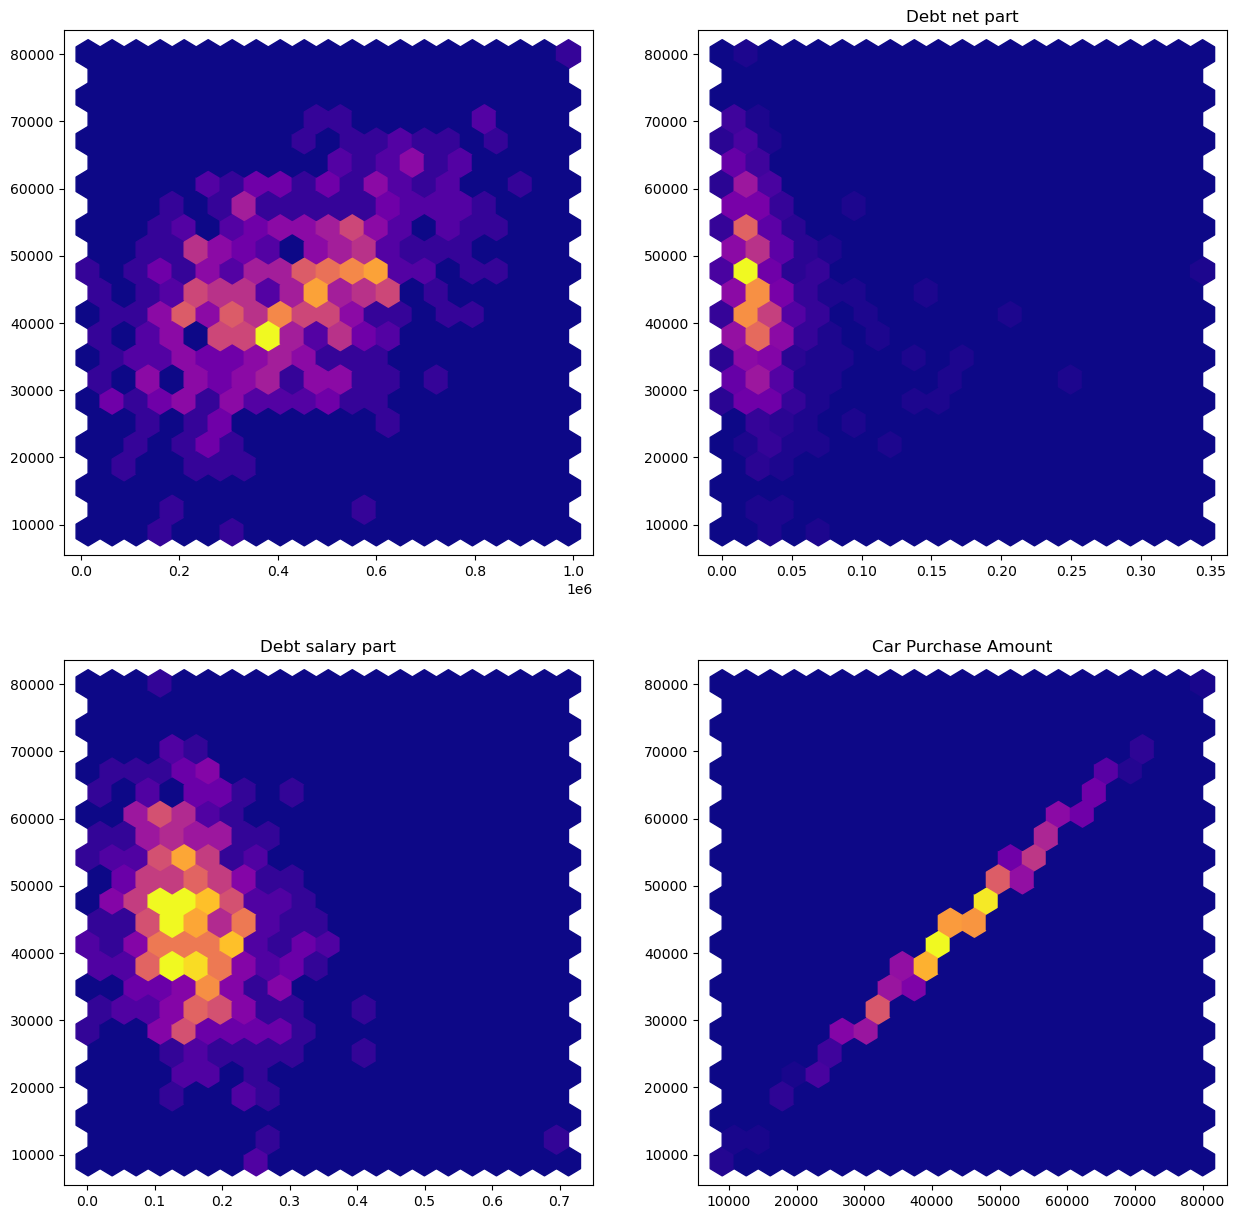

In [286]:
fig , axes = plt.subplots(2, 2, figsize = (15, 15))
axes[0,0].hexbin(ds_mod.All_money, ds_mod["Car Purchase Amount"], cmap= "plasma", gridsize=20, alpha = 1)

axes[0,1].hexbin(ds_mod.Debt_net_part, ds_mod["Car Purchase Amount"], cmap= "plasma", gridsize=20, alpha = 1)
axes[0,1].set_title("Debt net part")

axes[1,0].hexbin(ds_mod.Debt_salary_part, ds_mod["Car Purchase Amount"], cmap= "plasma", gridsize=20, alpha = 1)
axes[1,0].set_title("Debt salary part")

axes[1,1].hexbin(ds_mod["Car Purchase Amount"], ds_mod["Car Purchase Amount"], cmap= "plasma", gridsize=20, alpha = 1)
axes[1,1].set_title("Car Purchase Amount")
plt.show()

Тут мы можем отчётливо видеть, что Debt salary part и Debt net part вообще никак не коррелируют с целевым признаком. Теперь можно перейти к отбору ценных признаков.

Отбор признаков
-

Для отбора признаков будем использовать SelectKBest вместе с  f_regression, mutual_info_regression. На сколько я понял (а возможно я понял неправильно) SelectKBest служит только для такого, чтобы я мог выбрать. сколько значений будет выбрано. Я предалагаю начать с 4 признаков, так как суммарно +- нормально коррелирующих признаков и есть 4. Для начала я удалю Month Salary, так как тот призак по сути дубликат Annual Salary. Также считаю, что можно смело убрать имя человека, домен, e-mail и страну, так как эти признаки не имеют ценности по выше описанным причинам

In [287]:
ds_mod.drop(["Month_Salary"], axis = 1,inplace=True)
ds_mod.drop(["Customer Name"], axis = 1,inplace=True)
ds_mod.drop(["Customer e-mail"], axis = 1,inplace=True)
ds_mod.drop(["Country"], axis = 1,inplace=True)
ds_mod.drop(["Customer_domen"], axis = 1,inplace=True)

In [288]:
f_selectorbest = SelectKBest(f_regression, k = 4)
m_selector = SelectKBest(mutual_info_regression, k = 4)

Y_mod = ds_mod["Car Purchase Amount"]
non_goal_colomns = [x for x in ds_mod.columns if x != "Car Purchase Amount"]
X_mod = ds_mod[non_goal_colomns]

fit_f = f_selectorbest.fit(X_mod, Y_mod)
fit_m = m_selector.fit(X_mod, Y_mod)

p_values = fit_f.pvalues_
f_statics = fit_f.scores_

mi = fit_m.scores_

Хочу заметить , что SelectkBest тут бесполезен , так как мы не применяем transform и по сути не применяем главную суть SelectKBest - найти заданное количество лучших признаков. Теперь пере нами стоит задача собрать все полученные результаты в один дата сет и посмотреть на результаты и отобрать нужные мне парметры

In [289]:
select_results = pd.DataFrame({"Parametr" : ds_mod[non_goal_colomns].columns ,  "F_score":f_statics, "p_value" : p_values, "Mi":mi})

select_results.sort_values(by = "F_score", inplace=True)
select_results

,Parametr,F_score,p_value,Mi
3,Credit Card Debt,0.415776,5.193494e-01,0.000000
0,Gender,5.593142,1.841334e-02,0.004799
6,Debt_net_part,28.209050,1.644386e-07,0.012970
7,Debt_salary_part,43.895741,9.007210e-11,0.033910
5,All_money,155.179412,3.384381e-31,0.163438
4,Net Worth,156.153140,2.330089e-31,0.168185
2,Annual Salary,307.503396,5.756392e-54,0.201937
1,Age,333.432989,2.105472e-57,0.308166


Теперь хорошо видно, что лучшие признаки - All_money, Net Worth, Annual Salary, Age. теперь можно удалить другие и признаки и приступить уже непосредственно к обучению. 

In [290]:
ds_mod.drop(["Credit Card Debt", "Gender","Debt_net_part", "Debt_salary_part"], axis=1,inplace=True )

In [291]:
ds_mod.head()

,Age,Annual Salary,Net Worth,Car Purchase Amount,All_money
0,42,62812.09301,238961.2505,35321.45877,227351.869590
1,41,66646.89292,530973.9078,45115.52566,521400.950664
2,43,53798.55112,638467.1773,42925.70921,627306.822240
3,58,79370.03798,548599.0524,67422.36313,534172.887550
4,57,59729.15130,560304.0671,55915.46248,554945.354923


Перед переходои дальше стоит в начале разделить выборку на обучающую, контрольную и тестовую. 

In [292]:
X_mod = ds_mod[["Age", "Annual Salary","Net Worth","All_money"]]
Y_mod = ds_mod["Car Purchase Amount"]

X_mod_learn, X_mod_control, Y_mod_learn, Y_mod_control = train_test_split(X_mod, Y_mod, test_size=0.2)
X_mod_control, X_mod_test, Y_mod_control, Y_mod_test  = train_test_split(X_mod_control, Y_mod_control , test_size= 0.5)



Линейная модель
-

In [293]:
model_lasso_mod = Lasso(alpha=1, max_iter=1000)
model_lasso_mod.fit(X_mod_learn, Y_mod_learn)

y_pred_learn_mod = model_lasso_mod.predict(X_mod_learn)

R2_on_learn_mod = r2_score(Y_mod_learn, y_pred_learn_mod)
RMSE_on_learn_mod = np.sqrt(mean_squared_error(Y_mod_learn, y_pred_learn_mod))

print("RMSE on learn: ", RMSE_on_learn_mod)
print("R2 on learn: ", R2_on_learn_mod)

RMSE on learn:  239.81673948947792
R2 on learn:  0.9995175221941944


/home/ivankorolev/anaconda3/envs/envForML/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.184e+07, tolerance: 4.768e+06
  model = cd_fast.enet_coordinate_descent(


Тут мы видим интересное предупреждение - модель не сходится , я могу предположить, что это произошло из-за несмтабируемых данных, Почему это не происходило раньше ? не знаю, но факт остаётся фактом, других причит я не вижу. Раньше, возможно, на это влияли сторонние признаки, хотя не уверен.

In [294]:
y_pred_control_mod = model_lasso_mod.predict(X_mod_control)

R2_on_control_mod = r2_score(Y_mod_control, y_pred_control_mod)
RMSE_on_control_mod = np.sqrt(mean_squared_error(Y_mod_control, y_pred_control_mod))

print("RMSE on control: ", RMSE_on_control_mod)
print("R2 on control: ", R2_on_control_mod)

RMSE on control:  249.99383072119454
R2 on control:  0.9993806825120847


Мы можем видеть, что модель хорошо обучилась, однако ,хоть R2 и лучше чем у прошлых моделей, однако RMSE чуть хуже

Полиномиальная модель
-

Тут сразу будет использоваться метод с визуализацией , чтобы сыкономить время

In [295]:
degrees = [2,3,4,5,6,7, 8]
results_rmse = []
results_r2 = []
names = []
for degree in degrees:
    poly = PolynomialFeatures(degree)
    X_mod_learn_poly = poly.fit_transform(X_mod_learn)
    
    model = LinearRegression()
    model.fit(X_mod_learn_poly, Y_mod_learn)

    y_pred = model.predict(X_mod_learn_poly)

    rmse = np.sqrt(mean_squared_error(Y_mod_learn, y_pred))
    r2 = r2_score(Y_mod_learn, y_pred)

    results_rmse.append(rmse)
    results_r2.append(r2)
    names.append(degree)

    print("Degree: ", degree)
    print("RMSE: ",  rmse)
    print("R2: ", r2)

print("Names: ", names)
print("RMSE: ", results_rmse)
print("R2: ", results_r2)

Degree:  2
RMSE:  236.69438623717716
R2:  0.9995300038853836
Degree:  3
RMSE:  334.9032251976894
R2:  0.9990590706574412
Degree:  4
RMSE:  1160.5083839080312
R2:  0.9887016527928336
Degree:  5
RMSE:  1762.8809658074879
R2:  0.9739286014023022
Degree:  6
RMSE:  2468.2502286305767
R2:  0.9488910776192001
Degree:  7
RMSE:  3105.031254051871
R2:  0.9191182937891811
Degree:  8
RMSE:  3856.7347455940944
R2:  0.8752162901613996
Names:  [2, 3, 4, 5, 6, 7, 8]
RMSE:  [np.float64(236.69438623717716), np.float64(334.9032251976894), np.float64(1160.5083839080312), np.float64(1762.8809658074879), np.float64(2468.2502286305767), np.float64(3105.031254051871), np.float64(3856.7347455940944)]
R2:  [0.9995300038853836, 0.9990590706574412, 0.9887016527928336, 0.9739286014023022, 0.9488910776192001, 0.9191182937891811, 0.8752162901613996]


Уже видны странные признаки, но предлагаю всё визуализировать

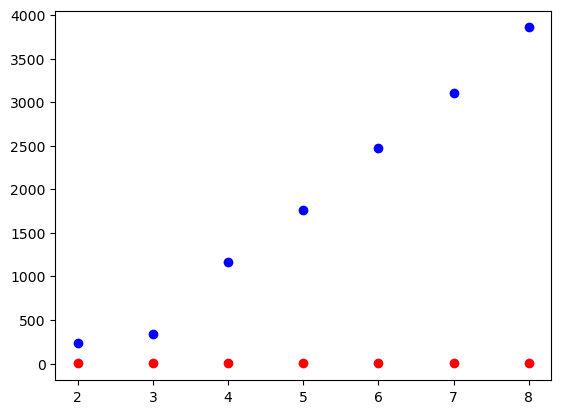

In [296]:
plt.plot(names, results_r2, "ro")
plt.plot(names, results_rmse, "bo")
plt.show()

Тут видно явное переобучения , особенно начиная с 4 степени, хотя на 3 оно только проявляется , перейдём к тестам на контрольной выборке

In [297]:
degrees = [2,3,4,5,6,7, 8]
results_rmse = []
results_r2 = []
names = []
for degree in degrees:
    poly = PolynomialFeatures(degree)
    X_mod_learn_poly = poly.fit_transform(X_mod_learn)
    X_mod_control_poly = poly.transform(X_mod_control)
    X_mod_control_poly.reshape(-1, 1)

    model = LinearRegression()
    model.fit(X_mod_learn_poly, Y_mod_learn)

    y_pred = model.predict(X_mod_control_poly)

    rmse = np.sqrt(mean_squared_error(Y_mod_control, y_pred))
    r2 = r2_score(Y_mod_control, y_pred)

    results_rmse.append(rmse)
    results_r2.append(r2)
    names.append(degree)

    print("Degree: ", degree)
    print("RMSE: ",  rmse)
    print("R2: ", r2)

print("Names: ", names)
print("RMSE: ", results_rmse)
print("R2: ", results_r2)

Degree:  2
RMSE:  248.66792220336788
R2:  0.9993872345195058
Degree:  3
RMSE:  435.32365134159363
R2:  0.9981220704873203
Degree:  4
RMSE:  1365.2065725413145
R2:  0.9815306546687732
Degree:  5
RMSE:  2299.3460555017573
R2:  0.9476081858053453
Degree:  6
RMSE:  4688.487681222916
R2:  0.7821686819858098
Degree:  7
RMSE:  6122.033657320626
R2:  0.6285963337186775
Degree:  8
RMSE:  5426.5937273117925
R2:  0.7081838135345049
Names:  [2, 3, 4, 5, 6, 7, 8]
RMSE:  [np.float64(248.66792220336788), np.float64(435.32365134159363), np.float64(1365.2065725413145), np.float64(2299.3460555017573), np.float64(4688.487681222916), np.float64(6122.033657320626), np.float64(5426.5937273117925)]
R2:  [0.9993872345195058, 0.9981220704873203, 0.9815306546687732, 0.9476081858053453, 0.7821686819858098, 0.6285963337186775, 0.7081838135345049]


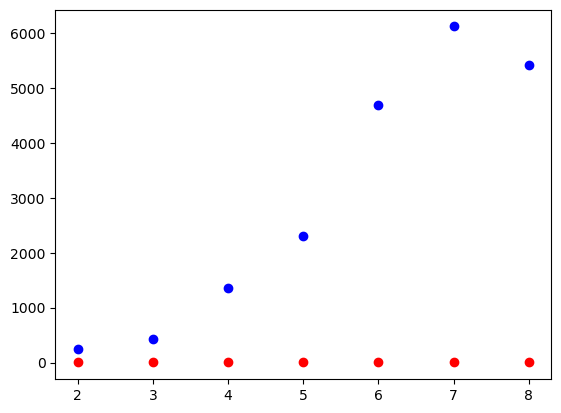

In [298]:
plt.plot(names, results_r2, "ro")
plt.plot(names, results_rmse, "bo")
plt.show()

Тут ситуация аналогична с прошлой, на степени 3 начинает возникать переобучение, которое лишь прогрессирует на старших степенях. так что как лучшую степень оставляем 2

Сравнение
-

In [299]:
RMSE_mod_control_lin = 255.1145943874145
R2_mod_control_lin =  0.9993631349570068

RMSE_mod_control_poly =  251.99905012450844
R2_mod_control_poly =  0.9993785951896538

Тут видно, что полиномиальная модель лучше по обеим метрикам

Работа с построенными масштабированными данными
=

Масштабирование
-

In [300]:
scaler = MinMaxScaler((0, 1), copy=True)

scaler.fit(X_mod_learn)

X_mod_scaled_learn = scaler.transform(X_mod_learn)
X_mod_scaled_control = scaler.transform(X_mod_control)
X_mod_scaled_test = scaler.transform(X_mod_test)

Линейная регрессия
-

In [301]:
model_lasso_scaled_mod = Lasso(alpha=0.5)
model_lasso_scaled_mod.fit(X_mod_scaled_learn, Y_mod_learn)

y_pred_learn_mod = model_lasso_scaled_mod.predict(X_mod_scaled_learn)

R2_on_learn_mod = r2_score(Y_mod_learn, y_pred_learn_mod)
RMSE_on_learn_mod = np.sqrt(mean_squared_error(Y_mod_learn, y_pred_learn_mod))

print("RMSE on learn: ", RMSE_on_learn_mod)
print("R2 on learn: ", R2_on_learn_mod)

RMSE on learn:  240.32711365885075
R2 on learn:  0.9995154664057919


Видим весьма хорошие результаты, проверим на контрольной выборке

In [302]:
y_pred = model_lasso_scaled_mod.predict(X_mod_scaled_control)
R2_on_learn_mod = r2_score(Y_mod_control, y_pred)
RMSE_on_learn_mod = np.sqrt(mean_squared_error(Y_mod_control, y_pred))

print("RMSE on control: ", RMSE_on_learn_mod)
print("R2 on control: ", R2_on_learn_mod)

RMSE on control:  249.32280964237583
R2 on control:  0.9993840027328647


Результаты слегка ухудшились, но это ожидаемо, теперь перейдём к полиномиальной регрессии

Полиномиальная регрессия
-

In [303]:
degrees = [2,3,4,5,6,7, 8]
results_rmse = []
results_r2 = []
names = []
for degree in degrees:
    poly = PolynomialFeatures(degree)
    X_mod_learn_poly = poly.fit_transform(X_mod_scaled_learn)
    
    model = LinearRegression()
    model.fit(X_mod_learn_poly, Y_mod_learn)

    y_pred = model.predict(X_mod_learn_poly)

    rmse = np.sqrt(mean_squared_error(Y_mod_learn, y_pred))
    r2 = r2_score(Y_mod_learn, y_pred)

    results_rmse.append(rmse)
    results_r2.append(r2)
    names.append(degree)

    print("Degree: ", degree)
    print("RMSE: ",  rmse)
    print("R2: ", r2)

print("Names: ", names)
print("RMSE: ", results_rmse)
print("R2: ", results_r2)

Degree:  2
RMSE:  236.69438612277497
R2:  0.9995300038858379
Degree:  3
RMSE:  234.61843718874994
R2:  0.9995382120167504
Degree:  4
RMSE:  216.53197614878812
R2:  0.9996066651464526
Degree:  5
RMSE:  199.99491559191483
R2:  0.9996644507580897
Degree:  6
RMSE:  172.22818907527886
R2:  0.9997511562012339
Degree:  7
RMSE:  109.09482188750486
R2:  0.9999001549296327
Degree:  8
RMSE:  29.067381799742797
R2:  0.9999929118943457
Names:  [2, 3, 4, 5, 6, 7, 8]
RMSE:  [np.float64(236.69438612277497), np.float64(234.61843718874994), np.float64(216.53197614878812), np.float64(199.99491559191483), np.float64(172.22818907527886), np.float64(109.09482188750486), np.float64(29.067381799742797)]
R2:  [0.9995300038858379, 0.9995382120167504, 0.9996066651464526, 0.9996644507580897, 0.9997511562012339, 0.9999001549296327, 0.9999929118943457]


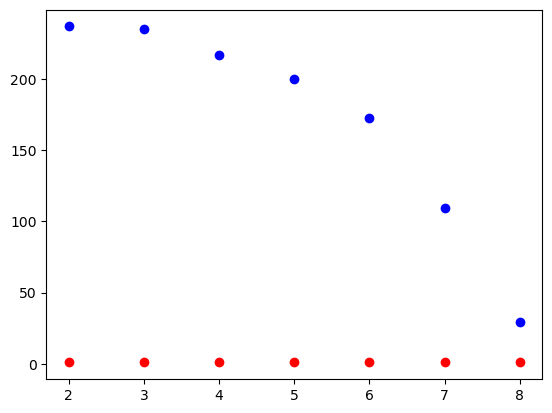

In [304]:
plt.plot(names, results_r2, "ro")
plt.plot(names, results_rmse, "bo")
plt.show()

Тут чем ближе к 8 тем лучшше rmse, но мне кажется, что это переобучение, посмотрим на контрольной выборке

In [305]:
degrees = [2,3,4,5,6,7, 8]
results_rmse = []
results_r2 = []
names = []
for degree in degrees:
    poly = PolynomialFeatures(degree)
    X_mod_learn_poly = poly.fit_transform(X_mod_scaled_learn)
    X_mod_control_poly = poly.transform(X_mod_scaled_control)
    X_mod_control_poly.reshape(-1, 1)

    model = LinearRegression()
    model.fit(X_mod_learn_poly, Y_mod_learn)

    y_pred = model.predict(X_mod_control_poly)

    rmse = np.sqrt(mean_squared_error(Y_mod_control, y_pred))
    r2 = r2_score(Y_mod_control, y_pred)

    results_rmse.append(rmse)
    results_r2.append(r2)
    names.append(degree)

    print("Degree: ", degree)
    print("RMSE: ",  rmse)
    print("R2: ", r2)

print("Names: ", names)
print("RMSE: ", results_rmse)
print("R2: ", results_r2)

Degree:  2
RMSE:  248.66878196488162
R2:  0.9993872302822638
Degree:  3
RMSE:  243.2234950944735
R2:  0.9994137730085796
Degree:  4
RMSE:  260.52311613275884
R2:  0.9993274148271882
Degree:  5
RMSE:  405.80932871162895
R2:  0.9983680801937241
Degree:  6
RMSE:  931.2113087639375
R2:  0.9914068727373018
Degree:  7
RMSE:  3884.5161233620533
R2:  0.8504699021435713
Degree:  8
RMSE:  195870.84038797783
R2:  -379.1844362980793
Names:  [2, 3, 4, 5, 6, 7, 8]
RMSE:  [np.float64(248.66878196488162), np.float64(243.2234950944735), np.float64(260.52311613275884), np.float64(405.80932871162895), np.float64(931.2113087639375), np.float64(3884.5161233620533), np.float64(195870.84038797783)]
R2:  [0.9993872302822638, 0.9994137730085796, 0.9993274148271882, 0.9983680801937241, 0.9914068727373018, 0.8504699021435713, -379.1844362980793]


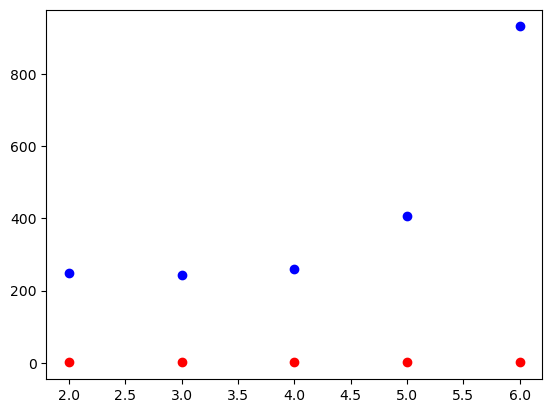

In [306]:
plt.plot(names[:-2], results_r2[:-2], "ro")
plt.plot(names[:-2], results_rmse[:-2], "bo")
plt.show()

Тут лучше всего показала степень 4, так что фиксируем её в памяти

Сравнение
-

In [307]:
RMSE_poly  =  248.44257276859875
R2_poly =  0.9993960112642016

RMSE_on_control_lin  = 254.81388740562014
R2_on_control_lin =  0.9993646354348433

Тут видно, что лучще всего себя покадзала полиномиальная модель. Пора переходить к выбору лучшей модели-набору

Итоговое сравнение и работа с лучшим
=

Сейчас посмотрю на лучше модели на каждом наборе и решу какой комплект лучше всего справляется с задачей 

In [308]:
Poly_origin_rmse = 238.39605496054642
Poly_origin_r2 = 0.9990665944836974

Linear_origin_scaled_rmse = 237.51655408350538
Linear_origin_scaled_r2 = 0.9990734688983232

Poly_mod_rmse = 251.99905012450844
Poly_mod_r2 = 0.9993785951896538

Poly_mod_scaled_rmse = 248.44257276859875
Poly_mod_scaled_r2 = 0.9993960112642016


Тут почти бесспорно выигрывать модель линейной регресии на масштабированном наборе данных, у неё лучшее RMSE, тогда как r2 отличается лишь незначительно. Меня только удивляет почему проиграли построенные наборы, возможно причина в придуманных мной признаках (они не подошли по большей части) , больше причин не могу предположить.  Я не буду исправлять это, хочу оставить как отпечаток моего опыта и малого познания предмета на данный момент.

Дальше проведём тесты на тестовой выборке для лушчей модели и попробуем изменять гиперпараметры 

In [309]:
res_model = Lasso(alpha=0.5)
res_model.fit(X_scaled_learn, Y_original_learn)

y_pred_lin_scaled_test = res_model.predict(X_scaled_test)

model_RMSE_scaled_test = np.sqrt(mean_squared_error(Y_original_test, y_pred_lin_scaled_test))
model_R2_scaled_test = r2_score(Y_original_test, y_pred_lin_scaled_test)

print("RMSE on test: ", model_RMSE_scaled_test)
print("R2 on test: ", model_R2_scaled_test)

RMSE on test:  229.73592851736464
R2 on test:  0.9994792788045777


Как видим очень даже хорошие результаты , теперь попробуем изменять гиперпараметр и проверять его на валидационном параметре,  а именно с alpha. Возьмём его для начала в промежутке от 0 до 10, а затем 50, 100, 200, чтобы обзорно посмотреть на всех возможных промежутках, потом будем углубляться в поиск, если понадобится 

In [310]:
alphas = [0.1, 0.5, 0.7, 1, 5, 10, 50, 100, 200]
results_rmse = []
results_r2 = []
names = []


for alpha in alphas:
    res_model = Lasso(alpha=alpha)
    res_model.fit(X_scaled_learn, Y_original_learn)

    y_pred = res_model.predict(X_scaled_control)

    rmse = np.sqrt(mean_squared_error(Y_original_control, y_pred))
    r2 = r2_score(Y_original_control, y_pred)

    print("Alpha: ", alpha)
    print("RMSE: ", rmse)
    print("R2: ", r2)

    results_r2.append(r2)
    results_rmse.append(rmse)
    names.append(alpha)

Alpha:  0.1
RMSE:  255.34501012578932
R2:  0.9994359606818115
Alpha:  0.5
RMSE:  255.00919021624188
R2:  0.9994374433117376
Alpha:  0.7
RMSE:  254.8695786727739
R2:  0.9994380591162757
Alpha:  1
RMSE:  254.69562309935583
R2:  0.9994388259350516
Alpha:  5
RMSE:  255.8441258814478
R2:  0.999433753502976
Alpha:  10
RMSE:  266.1606441501108
R2:  0.9993871667704486
Alpha:  50
RMSE:  552.2780817013274
R2:  0.9973614201382754
Alpha:  100
RMSE:  1037.035020961935
R2:  0.9906966047129254
Alpha:  200
RMSE:  2051.5111394621385
R2:  0.9635915335068161


Построим график получившихся значений

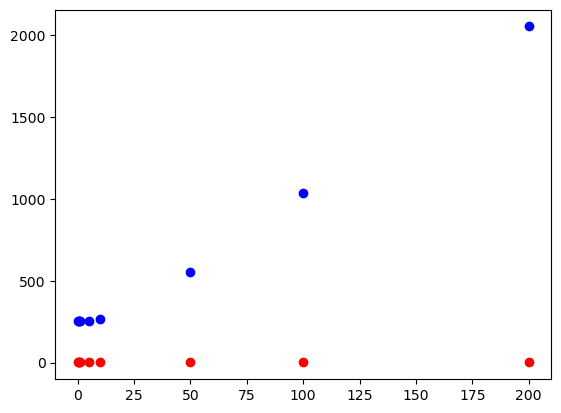

In [311]:
plt.plot(names, results_r2, "ro")
plt.plot(names, results_rmse, "bo")
plt.show()

После 10 явно переобучение происходит, так что построю график для значений до 10 включительно

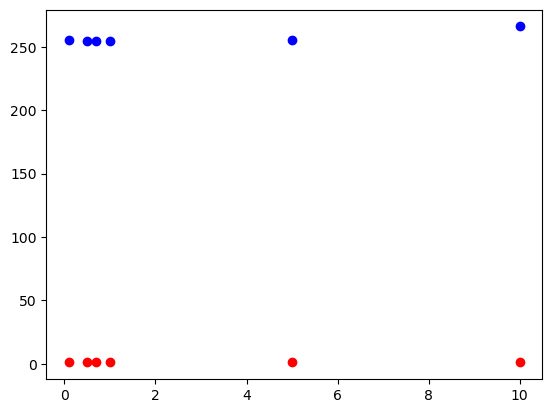

In [312]:
plt.plot(names[:-3], results_r2[:-3], "ro")
plt.plot(names[:-3], results_rmse[:-3], "bo")
plt.show()

По графику видно, что лучшее решение лежит где-то между 1 и 10, так что построю подробный график для него

In [313]:
alphas = np.arange(1, 10, 1)
results_rmse = []
results_r2 = []
names = []


for alpha in alphas:
    res_model = Lasso(alpha=alpha)
    res_model.fit(X_scaled_learn, Y_original_learn)

    y_pred = res_model.predict(X_scaled_control)

    rmse = np.sqrt(mean_squared_error(Y_original_control, y_pred))
    r2 = r2_score(Y_original_control, y_pred)

    print("Alpha: ", alpha)
    print("RMSE: ", rmse)
    print("R2: ", r2)

    results_r2.append(r2)
    results_rmse.append(rmse)
    names.append(alpha)

Alpha:  1
RMSE:  254.69562309935583
R2:  0.9994388259350516
Alpha:  2
RMSE:  254.42398559947506
R2:  0.9994400223013677
Alpha:  3
RMSE:  254.53554420293682
R2:  0.9994395311210592
Alpha:  4
RMSE:  254.98258832178746
R2:  0.9994375606745125
Alpha:  5
RMSE:  255.8441258814478
R2:  0.999433753502976
Alpha:  6
RMSE:  257.1159902942142
R2:  0.9994281096064499
Alpha:  7
RMSE:  258.79213183185607
R2:  0.9994206289849341
Alpha:  8
RMSE:  260.86475777181636
R2:  0.9994113116384287
Alpha:  9
RMSE:  263.32450609996533
R2:  0.9994001575669335


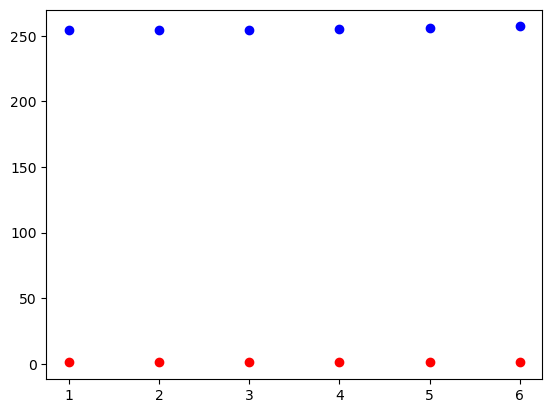

In [314]:
plt.plot(names[:-3], results_r2[:-3], "ro")
plt.plot(names[:-3], results_rmse[:-3], "bo")
plt.show()

График и цифры показали , что лучший результат достигается при alpha = 5, теперь осталось проверить этот результат на тестовой выборке

In [315]:
res_model = Lasso(alpha=5)
res_model.fit(X_scaled_learn, Y_original_learn)

y_pred = res_model.predict(X_scaled_test)

rmse = np.sqrt(mean_squared_error(Y_original_test, y_pred))
r2 = r2_score(Y_original_test, y_pred)


print("RMSE: ", rmse)
print("R2: ", r2)

RMSE:  226.65829725930493
R2:  0.9994931369189369


Тут мы можем увидеть, что результат улучшился по сравнению с alpha 0.5, что в целом является закономерным результатом.

Выводы
=


Итак, я считаю, что была проделана большая работа, были разобранные раные виды регрессий - полиномиальная и линейная Лассо, с разными наборами данных - стандартный, масштабированный, построенный и построенный масштабированный.
Были освоены все этапы разработки модели:

+ Разведовательный анализ данных
+ Одномерная визуализация
+ Двумерная визуализация
+ Изменение данных
+ Обучение моделей и сравнение на разных данных


В результате работы выяснили, что лучше всего работает Lasso регрессия с масштабированным набором данных. Это можно объяснить тем, что Lasso регрессия обнуляет все маловажные признаки, так что она автоматически избавляется от слабо коррелирующих значений. Так же это наталкивает на мысль, что параметры имеют линейную зависимость, что обеспечивает избыточность полиномиальной регрессии.

Отдельно стоит отметить, что построенные данные не показали себя должным образом возможно из-за того, что дополнительные признаки не несли особой ценности,а удалённые несли небольшой вклад, что и сказалось на результате.

Ещё из полученные навыков хотелось бы отметить практику в построении графиков.

Лучшие метрики, которых удалось добиться:

+ RMSE on test:  226.65829725930493
+ R2 on test:  0.9994931369189369


Как доп.комментарий хотелось бы сказать, что считать анализ полностью достоверным я бы не стал, потому что выборка довольно маленькая и содержит далеко не всё разнообразие данных, какое могло бы быть. Однако же полученную модель в приципе можно использовать

